# Exercise 1: data blocking

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

/tmp/ipykernel_8637/4237601810.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot([df['xmin'][i], df['xmax'][i]], [df['ymin'][i], df['ymax'][i]], 'b-',color=col)  # barretta inclinata


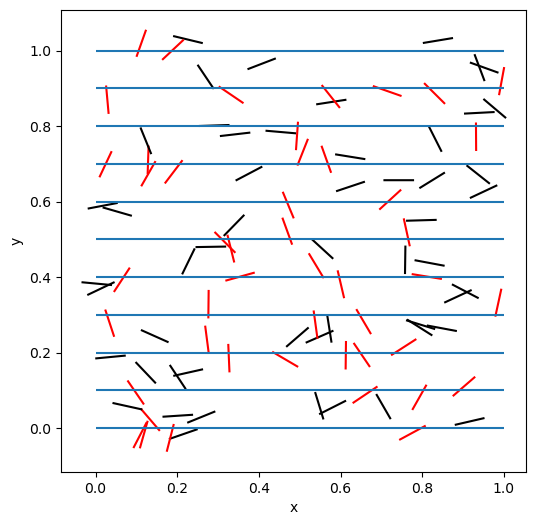

In [26]:
import matplotlib.pyplot as plt


df = pd.read_csv('./OUTPUT/needle_positions.csv',sep='\t')
plt.figure(figsize=(6,6))
for i in range(len(df['xmin'])):
    if(df['hit'][i]==1) :col='red'
    else :col='black'
    plt.plot([df['xmin'][i], df['xmax'][i]], [df['ymin'][i], df['ymax'][i]], 'b-',color=col)  # barretta inclinata
lines = np.linspace(0,1,11)
for h in lines:
    plt.hlines(h,0,1)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 1.1
**Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:
$\langle r \rangle = \int_0^1 r dr = 1/2$. ake a picture of the estimation of $\langle r \rangle$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$**

In [2]:
M=10000             # Total number of throws
N=100                 # Number of blocks
L=int(M/N)  

x = np.arange(N) *L

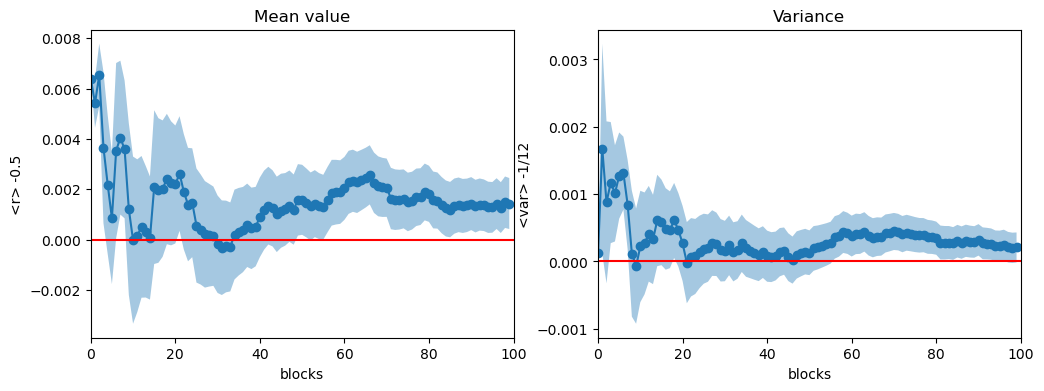

In [24]:
# Plot media

fig,ax=plt.subplots(1,2,figsize=(12,4))
df = pd.read_csv('./integral.csv', sep = '\t')
ax[0].plot(df['block'], df['block_ave']-0.5, marker='o')
ax[0].fill_between(df['block'], df['block_ave']-0.5-df['err'], df['block_ave']-0.5+df['err'],alpha = 0.4)
df = pd.read_csv('./variance.csv', sep = '\t')
ax[1].plot(df['block'], df['block_ave']-1/12, marker='o')
ax[1].fill_between(df['block'], df['block_ave']-1/12-df['err'], df['block_ave']-1/12+df['err'],alpha = 0.4)
# Labels and grid
for axes in ax:
    axes.set_xlabel('blocks')
    axes.hlines(0,100,0,color='red')
    axes.set_xlim(0,100)
ax[0].set_ylabel('<r> -0.5')
ax[0].set_title("Mean value")
ax[1].set_title("Variance")
ax[1].set_ylabel('<var> -1/12')
plt.show()


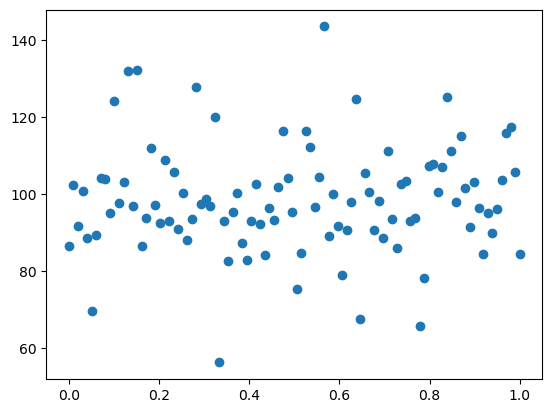

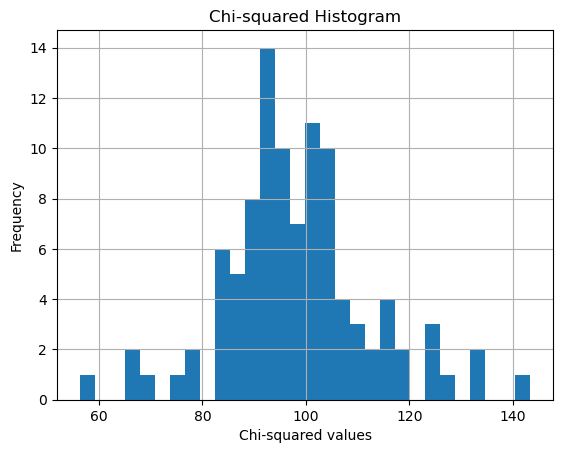

In [25]:
with open("Chi.txt", 'r') as file:
    chi_squared = np.array([float(line.strip()) for line in file if line.strip()])

x_values = np.linspace(0, 1, len(chi_squared))
plt.figure()
plt.scatter(x_values,chi_squared)
plt.figure()
plt.hist(chi_squared, bins=30)
plt.xlabel('Chi-squared values')
plt.ylabel('Frequency')
plt.title('Chi-squared Histogram')
plt.grid(True)
plt.show()

## 1.2
1. **Add two probability distributions by using the method of the inversion of the cumulative distribution to sample from a generic exponential distribution, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Exponential_distribution">this Wikipedia link</a>), and a **generic** Cauchy-Lorentz distribution $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">this Wikipedia link</a>).**
2. **Make 3 pictures with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).**

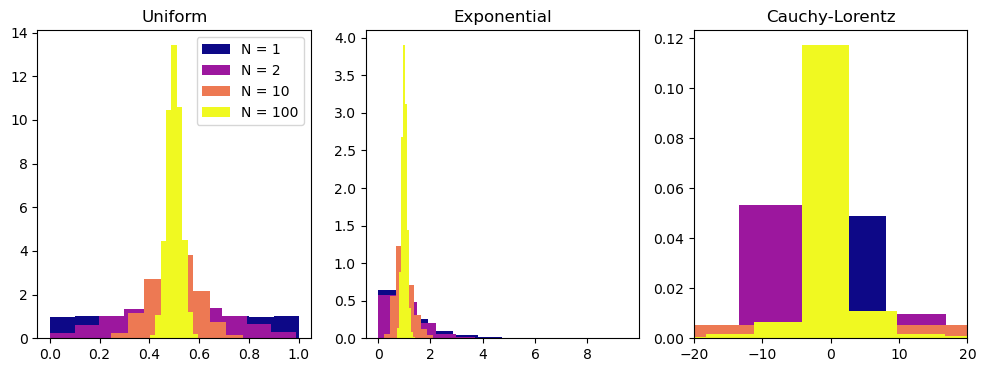

In [13]:

df1 = pd.read_csv("./OUTPUT/SN_unif.csv", sep ='\t')
df2 =pd.read_csv("./OUTPUT/SN_exp.csv", sep ='\t')
df3=pd.read_csv("./OUTPUT/SN_cauchy.csv", sep ='\t')
N_values = df1['N'].unique()

cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(N_values)))
fig,ax= plt.subplots(1,3,figsize=(12,4))

for i,val in enumerate(N_values):
    ax[0].hist(df1[df1['N'] == val]['SN'],  color=colors[i],label=f'N = {val}',density=True)
    ax[1].hist(df2[df2['N'] == val]['SN'], color=colors[i],label=f'N = {val}',density=True)
    ax[2].hist(df3[df3['N'] == val]['SN'], bins=1000, color=colors[i],label=f'N = {val}',density=True)
   

ax[0].set_title('Uniform')
ax[0].legend()
ax[1].set_title('Exponential')
ax[2].set_title('Cauchy-Lorentz')
ax[2].set_xlim(-20,20)
plt.show()

## 1.3

<ErrorbarContainer object of 3 artists>

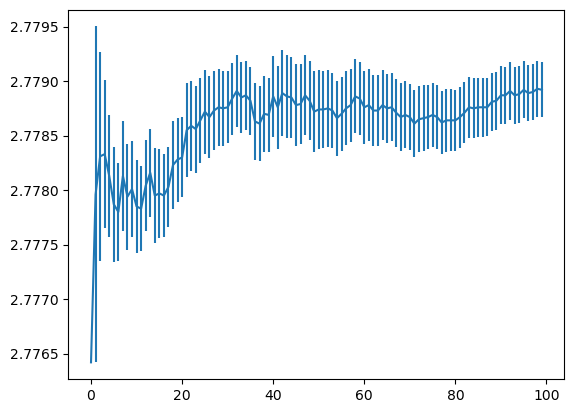

In [4]:
df=pd.read_csv("./OUTPUT/pi_ave.csv",sep='\t')
plt.errorbar(df['block'],df['block_ave'],yerr=df['err'])